## Objectif du TD N°1 interpretable Machine Learning


Ce td vise à interpréter les modèles de machine learning que vous avez crées lors du TD N°2 SVM.

Vous chercherez à interpréter globalement votre modèle avec les méthodes vues en cours et surtout examiner la différence entre des modèles linéaires et non linéaires.


## Enoncé du TD

### Importer le modèle du TD N°2

1. Importer le jeu de données breast cancer disponible dans le module sklearn.datasets
2. Importer un modèle non linéaire utilisé lors du TD N°2 ou alors recréer l'ensemble de la pipeline visant à le générer
3. Vérifier que votre modèle réalise correctement une prédiction pour un individu


### Comparer interprétation des coéfficients et méthode globale

4. Lancer un modèle de régression logistique sur le jeu de données data breast cancer et interpréter les résultats
5. Utiliser maintenant les différentes méthodes d'interprétation de modèle avec les résultats de le résultats des coefficients de la reg logistique
   1. Partial depence plot
   2. Accumulated Local Effect
   3. H-Statistic
   4. Feature permutation 
6. Commenter

### Interpréter un modèle non linéaire

7. Interpréter votre modèle non linéaire (SVM avec noyau) avec l'aide des méthodes globales
8. Commenter la différence de résultat






## Partie Code

#### 1)Importer le jeu de données breast cancer disponible dans le module sklearn.datasets

In [49]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import pickle

# Importation des bibliothèques nécessaires
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer

from artemis.interactions_methods.model_agnostic import FriedmanHStatisticMethod

import warnings
import matplotlib.pyplot as plt


In [35]:
#Load dataset breast cancer
data = load_breast_cancer()

breast = pd.DataFrame(data = np.c_[data.data,data.target], columns=list(data.feature_names)+['target'] )
#Nom des colonnes et remplacer les espaces par un "_"
features_name = [name.replace(" ", "_") for name in data.feature_names]
breast.columns= features_name+['target']

In [36]:
# On inverse la modalité de référence car on veut savoir s'il s'agit d'un cancer 
breast.target = 1- breast.target

In [37]:
# Calcul de la corrélation
m_corr = breast[features_name].corr(method="spearman")

# Partie supérieure de la matrice de corrélation (symétrique)
upper_tri = m_corr.where(np.triu(np.ones(m_corr.shape), k=1).astype(bool))

# Suppression des colonnes avec corrélation supérieure à 0.85
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

# Drop des colonnes trop corrélées
breast_no_corr = breast.drop(to_drop, axis=1)
training_features = breast_no_corr.columns[:-1]

# Affichage des résultats
print(f"Colonnes supprimées : {to_drop}")
print(f"Features retenues : {training_features}")

Colonnes supprimées : ['mean_perimeter', 'mean_area', 'mean_concavity', 'mean_concave_points', 'perimeter_error', 'area_error', 'concavity_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_compactness', 'worst_concavity', 'worst_concave_points']
Features retenues : Index(['mean_radius', 'mean_texture', 'mean_smoothness', 'mean_compactness',
       'mean_symmetry', 'mean_fractal_dimension', 'radius_error',
       'texture_error', 'smoothness_error', 'compactness_error',
       'concave_points_error', 'symmetry_error', 'fractal_dimension_error',
       'worst_smoothness', 'worst_symmetry', 'worst_fractal_dimension'],
      dtype='object')


#### 2) Recréer l'ensemble de la pipeline visant à générer un SVM non linéaire (RBF ou degree >1)


In [38]:
# Division des données en ensemble d'entraînement et de test

# Sélectionner les colonnes des variables explicatives (toutes sauf 'target' et 'target_name')
X = breast_no_corr.drop(columns=['target'])

# Sélectionner la colonne de la variable cible
y = breast_no_corr['target']

# Séparation des données en ensemble d'entraînement et ensemble de test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    shuffle=True, 
                                                    random_state=42)

In [39]:
# Définir une pipeline avec StandardScaler et SVM (Polynomial Kernel)
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Étape de normalisation
    ('svm', SVC(kernel='poly', random_state=42))  # SVM avec noyau polynomial
])

# Définir les hyperparamètres à tester pour le SVM avec noyau polynomial
param_grid = {
    'svm__C': [0.1, 0.5, 1, 10, 100],  # Hyperparamètre C
    'svm__degree': [2, 3, 4],  # Hyperparamètre degree pour le noyau polynomial
    'svm__gamma': ['scale', 'auto']  # Hyperparamètre gamma (ajusté pour noyau polynomial)
}

# Configurer une recherche sur grille pour optimiser les hyperparamètres
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # Validation croisée à 5 folds
    scoring='accuracy',  # Mesure de performance : précision
    verbose=1
)

# Entraîner la recherche sur grille
grid_search.fit(X_train, y_train)

# Résultats du meilleur modèle
best_model = grid_search.best_estimator_
print("\nMeilleurs paramètres trouvés :")
print(grid_search.best_params_)

# Évaluer les performances sur les données de test
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy avec le meilleur modèle polynomial : {accuracy:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres trouvés :
{'svm__C': 10, 'svm__degree': 3, 'svm__gamma': 'scale'}

Accuracy avec le meilleur modèle polynomial : 0.9123

Rapport de classification :
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93        71
         1.0       0.95      0.81      0.88        43

    accuracy                           0.91       114
   macro avg       0.92      0.89      0.90       114
weighted avg       0.91      0.91      0.91       114



#### 3) Vérifier que votre modèle réalise correctement une prédiction pour un individu

In [40]:
# Sélectionner un individu dans les données de test
individu = X_test.iloc[0:1]  # Première ligne des données de test
true_label = y_test.iloc[0]  # Vraie classe associée

# Faire une prédiction avec le modèle optimisé
predicted_label = best_model.predict(individu)

# Afficher les résultats
print("Données de l'individu sélectionné :")
print(individu)
print("\nVraie classe :", true_label)
print("Classe prédite :", predicted_label[0])

# Vérification de la correspondance
if predicted_label[0] == true_label:
    print("\nLe modèle a correctement prédit la classe de cet individu.")
else:
    print("\nLe modèle a mal prédit la classe de cet individu.")


Données de l'individu sélectionné :
     mean_radius  mean_texture  mean_smoothness  mean_compactness  \
204        12.47          18.6          0.09965            0.1058   

     mean_symmetry  mean_fractal_dimension  radius_error  texture_error  \
204         0.1925                 0.06373        0.3961          1.044   

     smoothness_error  compactness_error  concave_points_error  \
204          0.006953            0.01911               0.01037   

     symmetry_error  fractal_dimension_error  worst_smoothness  \
204         0.01782                 0.003586            0.1426   

     worst_symmetry  worst_fractal_dimension  
204          0.3014                   0.0875  

Vraie classe : 0.0
Classe prédite : 0.0

Le modèle a correctement prédit la classe de cet individu.


#### 4) Lancer un modèle de régression logistique sur le jeu de données data breast cancer et interpréter les résultats

Ici, l'idée est de mobiliser vos connaissance du modèle de régression logistique et d'interpréter les effets des variables.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import statsmodels.api as sm

# Standardiser les données 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Instancier et entraîner un modèle de régression logistique
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_sc, y_train)

# Évaluer le modèle sur les données de test
y_pred = log_reg.predict(X_test_sc)


# Rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))


Rapport de classification :
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97        71
         1.0       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [42]:
# Matrice de confusion
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))


Matrice de confusion :
[[69  2]
 [ 2 41]]


In [43]:
# Coefficients du modèle de régression logistique (standardisés)
coefficients = log_reg.coef_[0]
intercept = log_reg.intercept_[0]

# Créer un DataFrame pour afficher les coefficients absolus et les trier
beta = pd.DataFrame(np.abs(coefficients), index=feature_names, columns=['abs(coef)'])
beta = beta.sort_values(by='abs(coef)', ascending=False)

print("\nCoefficients standardisés (valeurs absolues) :")
print(beta)


Coefficients standardisés (valeurs absolues) :
                         abs(coef)
mean_radius               2.629933
radius_error              1.987409
worst_symmetry            1.787324
mean_texture              1.163287
concave_points_error      1.133376
worst_smoothness          1.126245
symmetry_error            0.896777
fractal_dimension_error   0.839357
worst_fractal_dimension   0.736596
mean_fractal_dimension    0.697024
mean_compactness          0.481768
mean_symmetry             0.435361
compactness_error         0.251017
smoothness_error          0.163678
texture_error             0.126723
mean_smoothness           0.073729


In [44]:
#Examiner les effets relatifs

# Récupérer les coefficients (avec leurs signes)
beta = pd.DataFrame(log_reg.coef_[0], index=X.columns, columns=['coef'])

# Trier les coefficients par ordre décroissant en fonction de l'importance (valeur absolue)
beta_sorted = beta.sort_values(by='coef', ascending=False)

# Afficher les coefficients triés
print("\nCoefficients triés par ordre d'importance (avec signes) :")
print(beta_sorted)


Coefficients triés par ordre d'importance (avec signes) :
                             coef
mean_radius              2.629933
radius_error             1.987409
worst_symmetry           1.787324
mean_texture             1.163287
concave_points_error     1.133376
worst_smoothness         1.126245
worst_fractal_dimension  0.736596
mean_compactness         0.481768
texture_error            0.126723
mean_smoothness          0.073729
smoothness_error        -0.163678
compactness_error       -0.251017
mean_symmetry           -0.435361
mean_fractal_dimension  -0.697024
fractal_dimension_error -0.839357
symmetry_error          -0.896777


#### 5) Utiliser maintenant les différentes méthodes d'interprétations de modèle avec les résultats de le résultats des coéfficients de la reg logistique
   1. Partial depence plot
   2. Accumulated Local Effect
   3. H-Statistic
   4. Feature permutation 

#### 1. Partiel Depence Plot

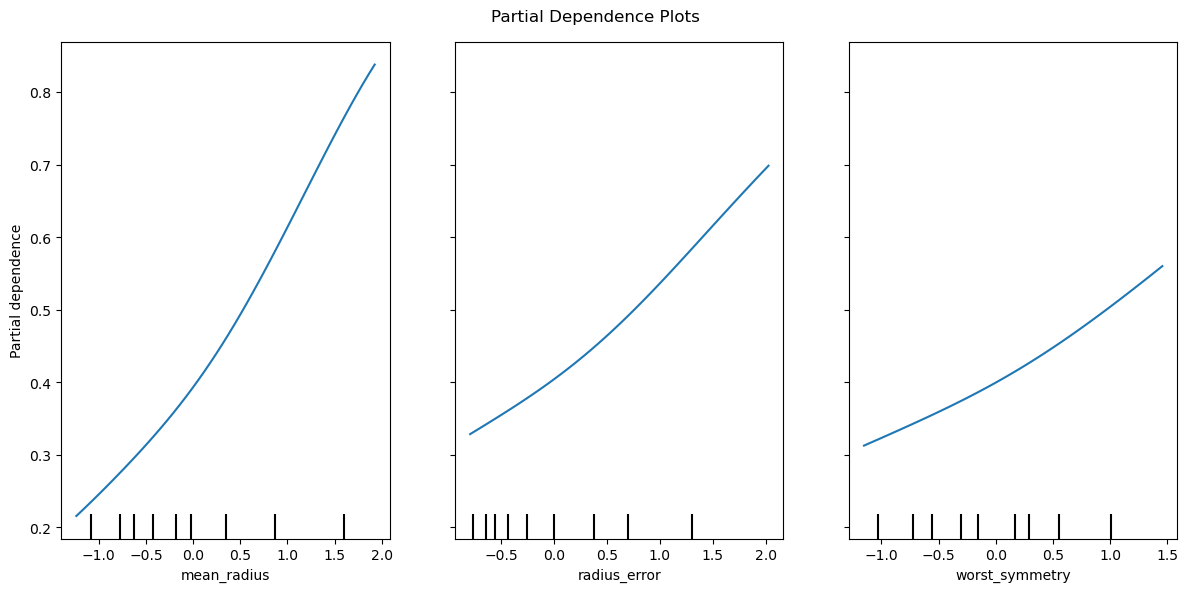

In [50]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Masquer les avertissements
warnings.filterwarnings("ignore")

df_interpret = pd.DataFrame(X_test_sc, columns = training_features)

# PDP pour plusieurs caractéristiques (par exemple, 'sepal length' et 'petal width')
features = ["mean_radius","radius_error","worst_symmetry"]  # Index des caractéristiques
_, ax1 = plt.subplots(figsize = (12,6))
PartialDependenceDisplay.from_estimator(log_reg,  #votre modèle
                                         df_interpret, 
                                         features,
                                         kind="average",
                                         ax = ax1,
                                         grid_resolution=50, # Nombre de points estimés pour le tracer de la courbe
                                         n_cols=3
                                         )
plt.suptitle("Partial Dependence Plots")
plt.tight_layout()
plt.show()

# Restaurer le comportement par défaut des avertissements
warnings.filterwarnings("default")

#### 2. Accumulated Local Effect

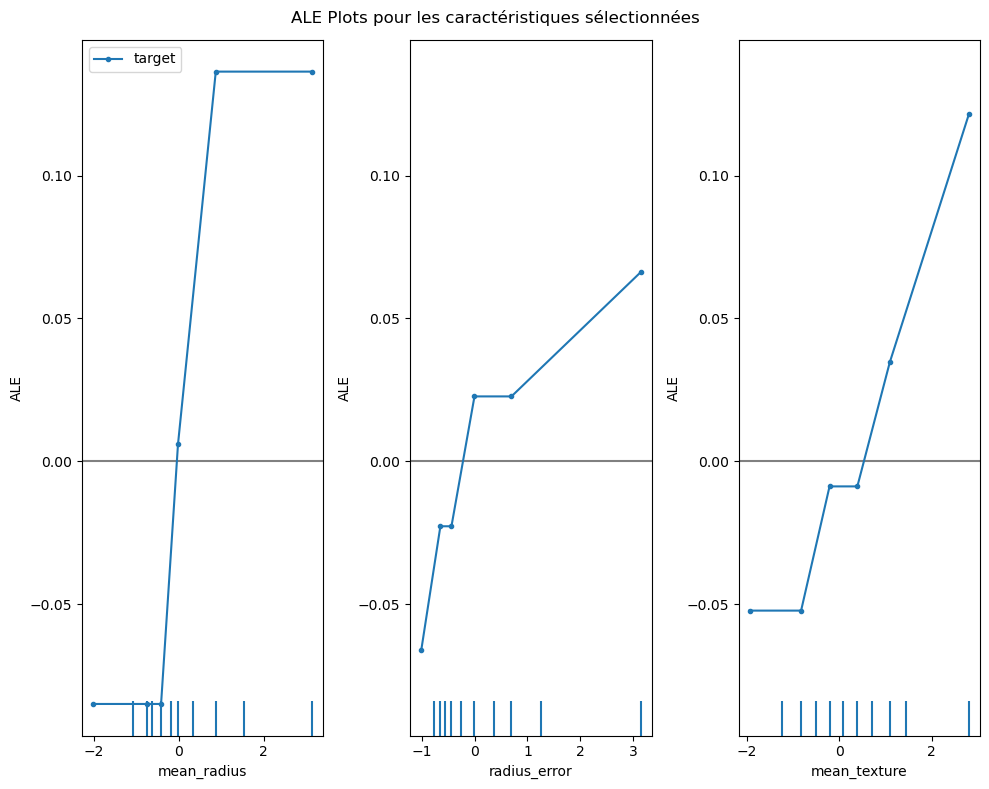

In [14]:
from alibi.explainers import ALE, plot_ale

# Créer l'explainer ALE pour le modèle de régression logistique
logistic_ale = ALE(log_reg.predict, feature_names=training_features, target_names=["target"])

# Expliquer les données d'entraînement
logistic_exp = logistic_ale.explain(X_test_sc, min_bin_points=20)

# Tracer les ALE plots pour les caractéristiques sélectionnées
_, ax1 = plt.subplots(figsize=(10, 8))
plot_ale(logistic_exp, features=["mean_radius", "radius_error", "mean_texture"], ax=ax1, targets=[0])
plt.suptitle("ALE Plots pour les caractéristiques sélectionnées")
plt.tight_layout()
plt.show()

#### 3. H-Statistic

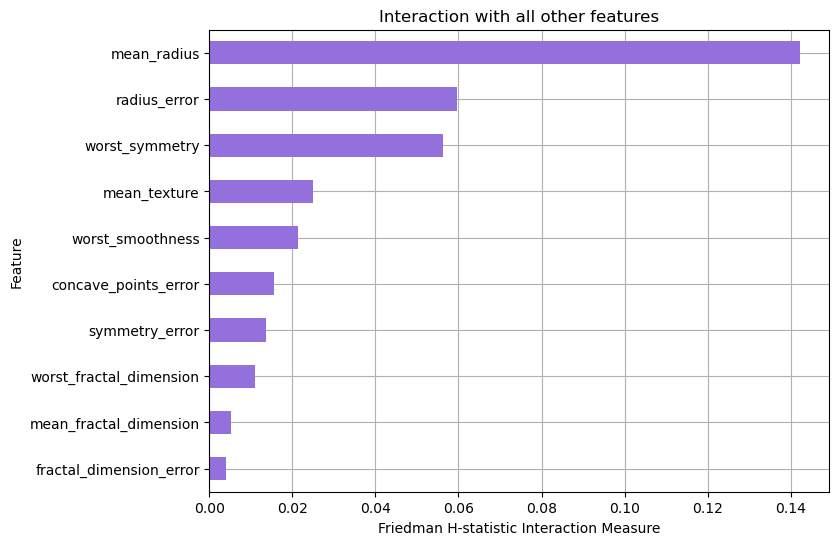

In [51]:
from artemis.interactions_methods.model_agnostic import FriedmanHStatisticMethod

# Masquer les avertissements
warnings.filterwarnings("ignore")

# Créer l'objet FriedmanHStatisticMethod
h_stat = FriedmanHStatisticMethod()

# Entraîner la méthode avec les données (en utilisant l'algorithme de régression logistique et les données de test)
h_stat.fit(log_reg, pd.DataFrame(X_test_sc, columns=training_features), batchsize=100)

# Visualiser les 10 meilleures caractéristiques (en fonction de la statistique H)
h_stat.plot(vis_type="bar_chart_ova", top_k=10)


# Restaurer le comportement par défaut des avertissements (facultatif)
warnings.filterwarnings("default")

#### 4. Feature permutation

In [46]:
from sklearn.inspection import permutation_importance


In [47]:
result = permutation_importance(log_reg, X_test_sc, y_test,
                                n_repeats=15,
                                random_state=0,
                                scoring='accuracy'
                                )

# Créer un DataFrame pour afficher l'importance des variables
importance_df = pd.DataFrame(result.importances_mean, index=training_features, columns=['P-importance'])

# Trier les variables par importance décroissante
importance_df_sorted = importance_df.sort_values(by="P-importance", ascending=False)

# Afficher le résultat trié
print(importance_df_sorted)

                         P-importance
mean_radius                  0.136257
radius_error                 0.069591
worst_symmetry               0.039181
mean_texture                 0.025146
worst_smoothness             0.020468
concave_points_error         0.019883
mean_fractal_dimension       0.010526
mean_symmetry                0.005848
compactness_error            0.005848
fractal_dimension_error      0.003509
worst_fractal_dimension      0.002924
symmetry_error               0.001754
mean_smoothness              0.000000
texture_error                0.000000
smoothness_error             0.000000
mean_compactness            -0.002924


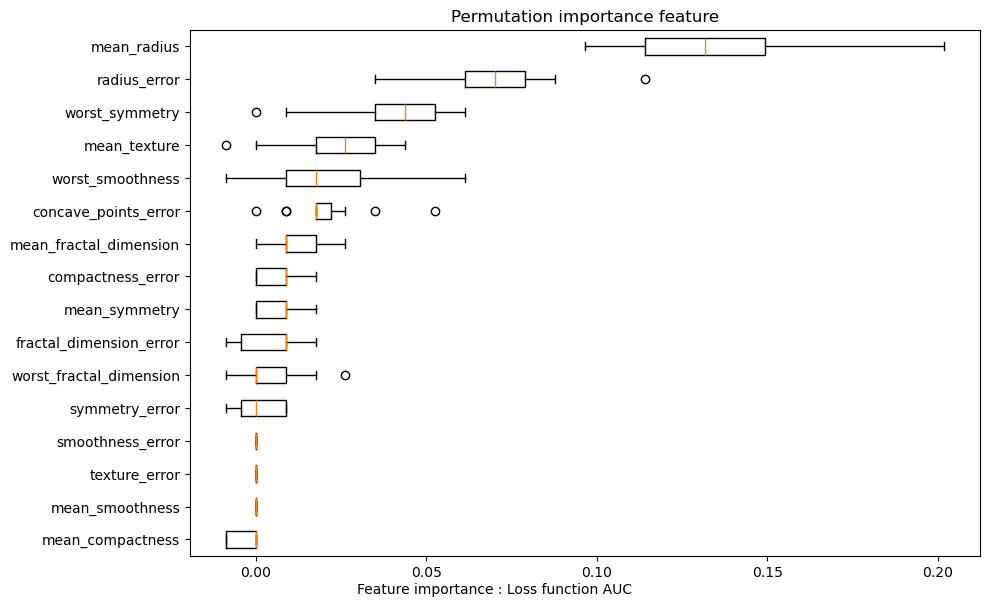

In [52]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

perm_sorted_idx = result.importances_mean.argsort()

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))
ax1.boxplot(
    result.importances[perm_sorted_idx].T,
    vert=False,
    labels=training_features[perm_sorted_idx]
)
plt.title('Permutation importance feature')
fig.text(.5, .001, "Feature importance : Loss function AUC", ha='center')

fig.tight_layout()
plt.show()

# Restaurer le comportement par défaut des avertissements (facultatif)
warnings.filterwarnings("default")

#### 6) Commenter et discuter des limites

#### 7) Interpréter votre modèle non linéaire (SVM avec noyau) avec l'aide des méthodes globales

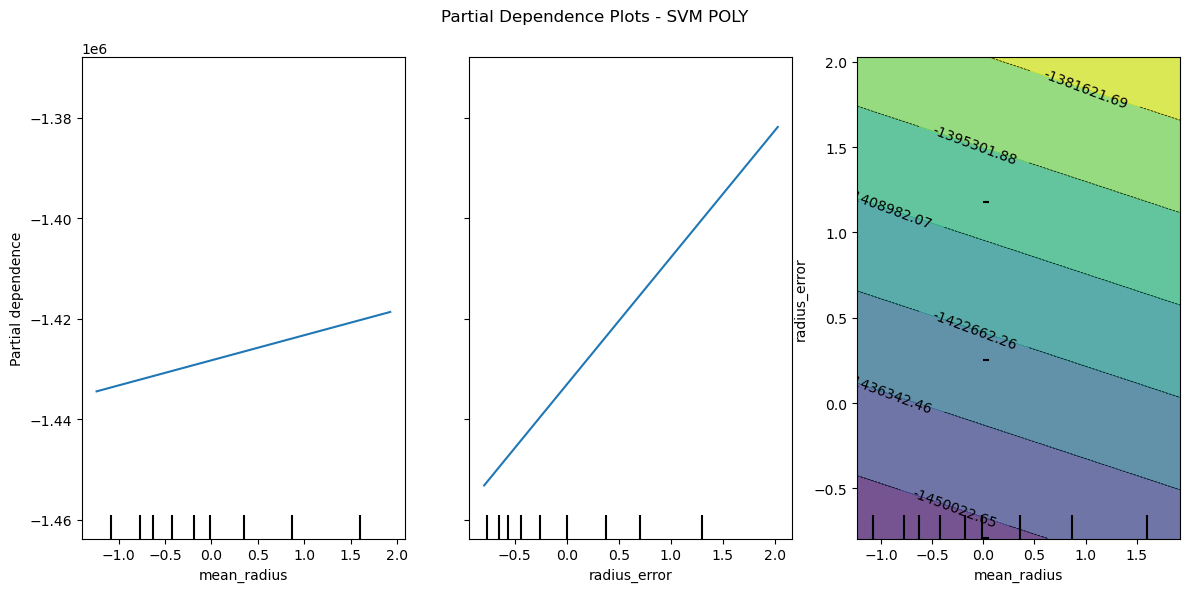

In [53]:
# PDP pour plusieurs caractéristiques (par exemple, 'sepal length' et 'petal width')
features = ["mean_radius","radius_error" ,('mean_radius','radius_error')]  # Index des caractéristiques
_, ax1 = plt.subplots(figsize = (12,6))
PartialDependenceDisplay.from_estimator(best_model,  #votre modèle
                                         df_interpret, 
                                         features,
                                         kind="average",
                                         ax = ax1,
                                         grid_resolution=100, # Nombre de points estimés pour le tracer de la courbe
                                         n_cols=3
                                         )
plt.suptitle("Partial Dependence Plots - SVM POLY")
plt.tight_layout()
plt.show()

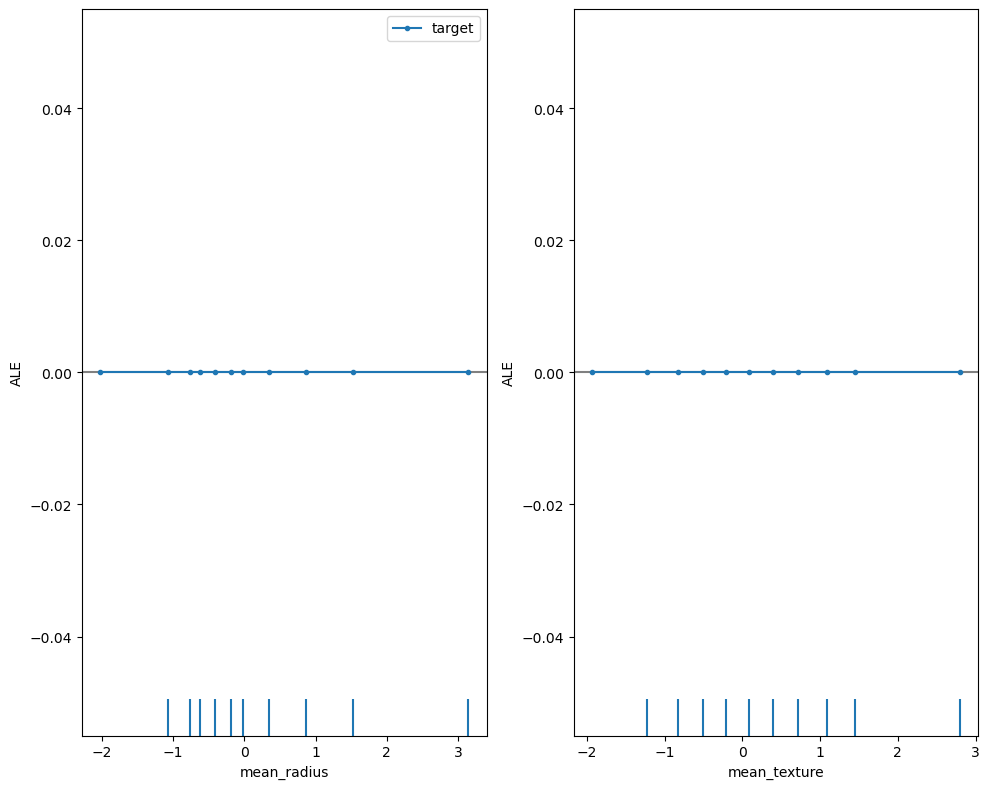

In [56]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

svm_ale = ALE(best_model.predict, feature_names=training_features, target_names=["target"])
svm_exp = svm_ale.explain(X_test_sc, min_bin_points=10)
_, ax1 = plt.subplots(figsize = (10,8))
plot_ale(svm_exp, features=["mean_radius","mean_texture"], ax= ax1, targets=[0])


# Restaurer le comportement par défaut des avertissements (facultatif)
warnings.filterwarnings("default")

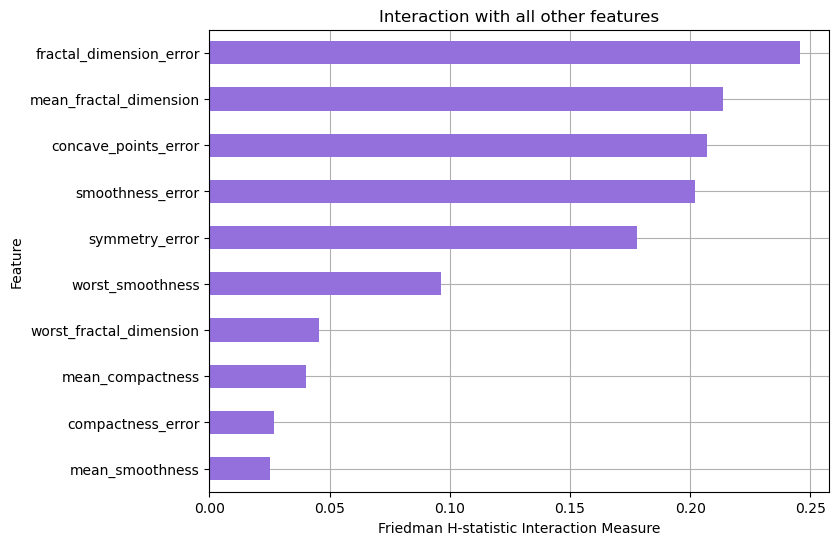

In [58]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

h_stat = FriedmanHStatisticMethod()
h_stat.fit(best_model, pd.DataFrame(X_test_sc, columns=training_features), batchsize=20)
# Interaction One vs All
h_stat.plot(vis_type="bar_chart_ova",top_k=10 )

# Restaurer le comportement par défaut des avertissements (facultatif)
warnings.filterwarnings("default")

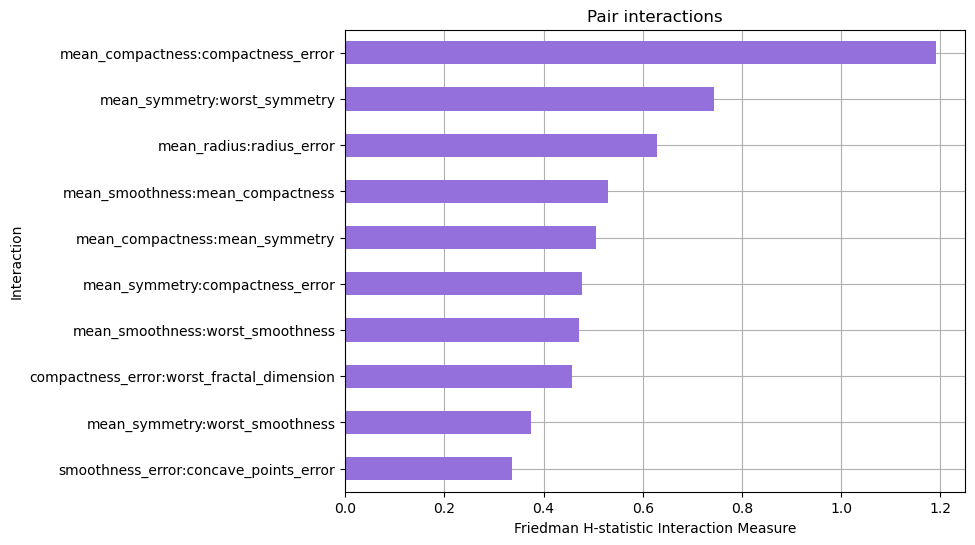

In [59]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

# Interaction One vs All
h_stat.plot(vis_type="bar_chart",top_k=10 )

# Restaurer le comportement par défaut des avertissements (facultatif)
warnings.filterwarnings("default")

In [61]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

result = permutation_importance(best_model, X_test_sc, y_test,
                           n_repeats=15,
                           random_state=0,
                           scoring="accuracy"
                           )

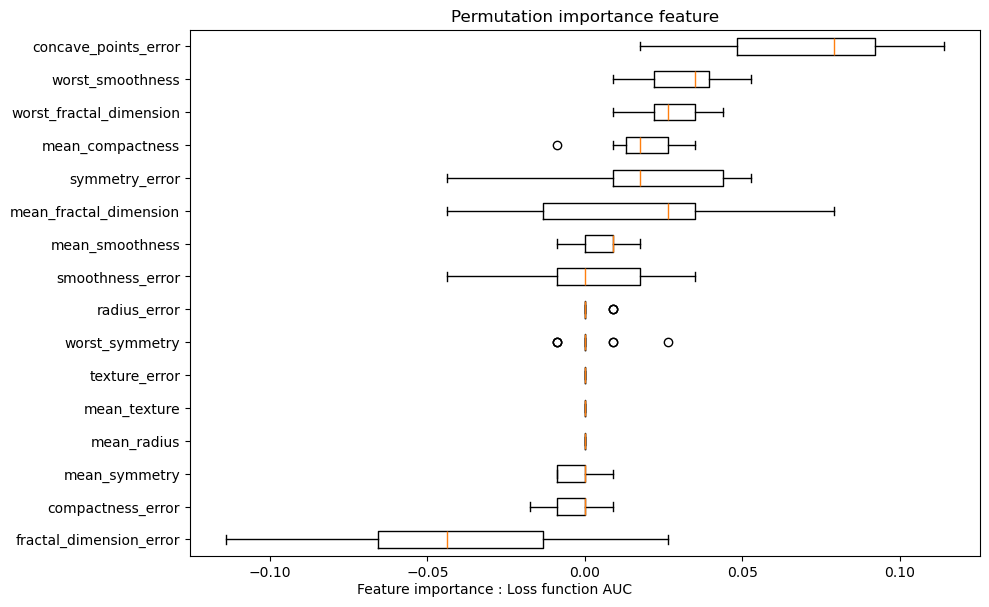

In [62]:
perm_sorted_idx = result.importances_mean.argsort()

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))
ax1.boxplot(
    result.importances[perm_sorted_idx].T,
    vert=False,
    labels=training_features[perm_sorted_idx]
)
plt.title('Permutation importance feature')
fig.text(.5, .001, "Feature importance : Loss function AUC", ha='center')

fig.tight_layout()
plt.show()